In [ ]:
#r "nuget: ScottPlot, 5.0.*"

: 

In [4]:
#r "./bin/Debug/net9.0/Helix.ML.dll"

In [12]:
using Helix.ML.LinAlg;
using ScottPlot;

Console.WriteLine("Math Engine and Plotting Library loaded!");

Math Engine and Plotting Library loaded!



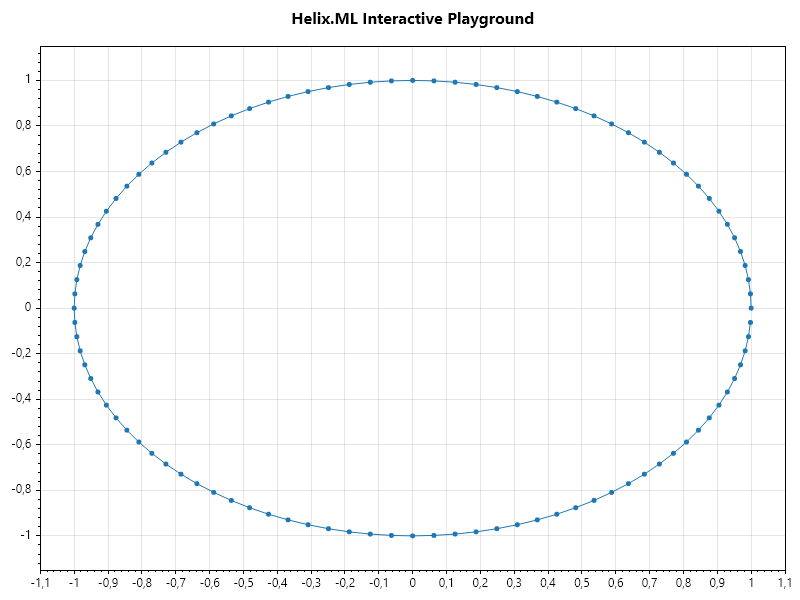


warning CS1701: Assuming assembly reference 'Microsoft.AspNetCore.Html.Abstractions, Version=2.2.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' used by 'Microsoft.DotNet.Interactive' matches identity 'Microsoft.AspNetCore.Html.Abstractions, Version=8.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' of 'Microsoft.AspNetCore.Html.Abstractions', you may need to supply runtime policy



In [14]:
// Generate a circle of data points
int points = 100;
double[] xs = new double[points];
double[] ys = new double[points];

for (int i = 0; i < points; i++)
{
    double angle = i * Math.PI * 2 / points;
    xs[i] = Math.Cos(angle);
    ys[i] = Math.Sin(angle);
}

// Create the plot
var plot = new ScottPlot.Plot();
plot.Add.Scatter(xs, ys);
plot.Title("Helix.ML Interactive Playground");

// Render the plot directly in the notebook output
byte[] imageBytes = plot.GetImageBytes(800, 600);
display(HTML($"<img src='data:image/png;base64,{Convert.ToBase64String(imageBytes)}' />"));

In [ ]:
using Helix.ML.LinAlg;
using Helix.ML.Stat;
using System;

// 1. REPRODUCIBLE DATASET 
// (A classic textbook example of linearly correlated points)
double[] rawData = [
    2.5, 2.4,
    0.5, 0.7,
    2.2, 2.9,
    1.9, 2.2,
    3.1, 3.0,
    2.3, 2.7,
    2.0, 1.6,
    1.0, 1.1,
    1.5, 1.6,
    1.1, 0.9
];
var data = new Matrix(10, 2, rawData);

// 2. RUN HELIX.ML PCA
var pca = new PCA();
pca.Fit(data);

// 3. PRINT EXACT NUMBERS FOR COMPARISON
Console.WriteLine("--- Helix.ML PCA Results ---");
Console.WriteLine($"Mean Vector: [{pca.MeanVector[0]:F4}, {pca.MeanVector[1]:F4}]");
Console.WriteLine($"PC1 Weights: [{pca.Components[0,0]:F4}, {pca.Components[1,0]:F4}]");
Console.WriteLine($"PC2 Weights: [{pca.Components[0,1]:F4}, {pca.Components[1,1]:F4}]");
Console.WriteLine($"Explained Variance Ratio: PC1={pca.ExplainedVarianceRatio[0]:F4}, PC2={pca.ExplainedVarianceRatio[1]:F4}");

// 4. VISUALIZATION
var plt = new ScottPlot.Plot();
plt.Title("Reproducible PCA");

// Extract columns for the scatter plot
double[] x = new double[10];
double[] y = new double[10];
for(int i = 0; i < 10; i++) 
{ 
    x[i] = data[i, 0]; 
    y[i] = data[i, 1]; 
}

var scatter = plt.Add.Scatter(x, y);
scatter.LineWidth = 0; // Dots only

double meanX = pca.MeanVector[0];
double meanY = pca.MeanVector[1];

// Draw PC1 (Red Line). Scaled by 1.5 just so it spans across the data points nicely.
double scale = 1.5; 
var line1 = plt.Add.Line(meanX, meanY, meanX + (pca.Components[0, 0] * scale), meanY + (pca.Components[1, 0] * scale));
line1.Color = ScottPlot.Colors.Red;
line1.LineWidth = 3;

byte[] imgBytes = plt.GetImageBytes(600, 400);
display(HTML($"<img src='data:image/png;base64,{Convert.ToBase64String(imgBytes)}' />"));

: 